# Import Library

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, r2_score, mean_absolute_percentage_error

df = pd.read_csv('Gold  Prices.csv')
df['Date'] = pd.to_datetime(df['Date'], utc=True)
df = df.sort_values('Date').reset_index(drop=True)

print("Dimensi Data Awal:", df.shape)
df.head()

Dimensi Data Awal: (1258, 9)


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
0,2019-11-11 05:00:00+00:00,137.610001,137.789993,136.440002,137.059998,7037300,0.0,0.0,0.0
1,2019-11-12 05:00:00+00:00,137.029999,137.589996,136.190002,137.429993,6448600,0.0,0.0,0.0
2,2019-11-13 05:00:00+00:00,137.800003,138.220001,137.639999,137.979996,8776000,0.0,0.0,0.0
3,2019-11-14 05:00:00+00:00,138.389999,138.940002,137.869995,138.559998,5220500,0.0,0.0,0.0
4,2019-11-15 05:00:00+00:00,138.029999,138.419998,137.970001,138.210007,10106700,0.0,0.0,0.0


# Feature Engineering

Membuat indikator teknis tambahan seperti return harian (Daily Return), Moving Average harian (MA5 & MA20), rata-rata volume (Vol_MA5), dan volatilitas harga untuk memperkaya informasi model.

In [44]:
df['Return'] = df['Close'].pct_change()
df['MA5'] = df['Close'].rolling(window=5).mean()
df['MA20'] = df['Close'].rolling(window=20).mean()
df['Vol_MA5'] = df['Volume'].rolling(window=5).mean()
df['Volatility'] = df['Return'].rolling(window=5).std()

df['Target_Close'] = df['Close'].shift(-1)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

feature_cols = [  'Open',
    'High',
    'Low',
    'Close',
    'Volume',
    'Return',
    'MA5',
    'MA20',
    'Vol_MA5',
    'Volatility'
]
X_raw = df[feature_cols].values
y_raw = df['Target_Close'].values


X_train, X_test, y_train, y_test = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_raw)
X_test = scaler.transform(X_test)

df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains,Return,MA5,MA20,Vol_MA5,Volatility,Target_Close
0,2019-12-09 05:00:00+00:00,137.800003,137.809998,137.449997,137.580002,2711600,0.0,0.0,0.0,-0.000291,138.445999,138.037999,6380320.0,0.006932,137.970001
1,2019-12-10 05:00:00+00:00,138.250000,138.330002,137.740005,137.970001,3240800,0.0,0.0,0.0,0.002835,138.217999,138.083499,5332140.0,0.004887,138.919998
2,2019-12-11 05:00:00+00:00,138.199997,139.300003,138.119995,138.919998,6097500,0.0,0.0,0.0,0.006886,138.217999,138.157999,5287180.0,0.006213,138.429993
3,2019-12-12 05:00:00+00:00,139.779999,139.850006,137.880005,138.429993,8815100,0.0,0.0,0.0,-0.003527,138.103998,138.180499,5915900.0,0.006389,139.050003
4,2019-12-13 05:00:00+00:00,138.520004,139.210007,137.979996,139.050003,6964300,0.0,0.0,0.0,0.004479,138.389999,138.205000,5565860.0,0.004077,139.039993


# Implementasi Algoritma Ant Colony 
Membuat kelas ACO berbasis biner untuk seleksi fitur. Setiap semut akan menentukan pilihan biner ( 0  atau  1 ) untuk mengaktifkan atau menonaktifkan suatu fitur berdasarkan konsentrasi feromon ( τ ). Kualitas jalur semut dievaluasi menggunakan nilai akurasi Cross-Validation.

In [45]:
class ACOFeatureSelection:
    def __init__(self, n_ants=10, n_iterations=10, alpha=1.0, evaporation=0.2, Q=1.0):
        self.n_ants = n_ants
        self.n_iterations = n_iterations
        self.alpha = alpha 
        self.evaporation = evaporation  
        self.Q = Q  #
    def fit(self, X, y):
        n_features = X.shape[1]
        pheromones = np.ones((n_features, 2))

        best_score = 0
        self.best_features_ = None

        for iteration in range(self.n_iterations):
            ant_histories = []
            ant_scores = []

            for ant in range(self.n_ants):
                selected = []
                for i in range(n_features):
                    p_0 = (pheromones[i, 0] ** self.alpha)
                    p_1 = (pheromones[i, 1] ** self.alpha)
                    prob_select = p_1 / (p_0 + p_1)

                    choice = 1 if np.random.rand() < prob_select else 0
                    selected.append(choice)

                selected = np.array(selected)
                if np.sum(selected) == 0: 
                    selected[np.random.randint(n_features)] = 1

                cols = np.where(selected == 1)[0]
                clf = RandomForestClassifier(n_estimators=20, random_state=42)
                score = np.mean(cross_val_score(clf, X[:, cols], y, cv=3))

                ant_histories.append(selected)
                ant_scores.append(score)

                if score > best_score:
                    best_score = score
                    self.best_features_ = selected

            pheromones *= (1 - self.evaporation)

            for selected, score in zip(ant_histories, ant_scores):
                for i in range(n_features):
                    if selected[i] == 1:
                        pheromones[i, 1] += self.Q * score
                    else:
                        pheromones[i, 0] += self.Q * score

        self.best_features_idx_ = np.where(self.best_features_ == 1)[0]
        self.best_score_ = best_score
        return self

print("Kelas ACO Berhasil Didefinisikan.")

Kelas ACO Berhasil Didefinisikan.


# Segmentasi Pasar (Clustering)
Mengelompokkan kondisi pergerakan harga emas harian ke dalam 3 kelompok market regime utama menggunakan algoritma  K -Means.

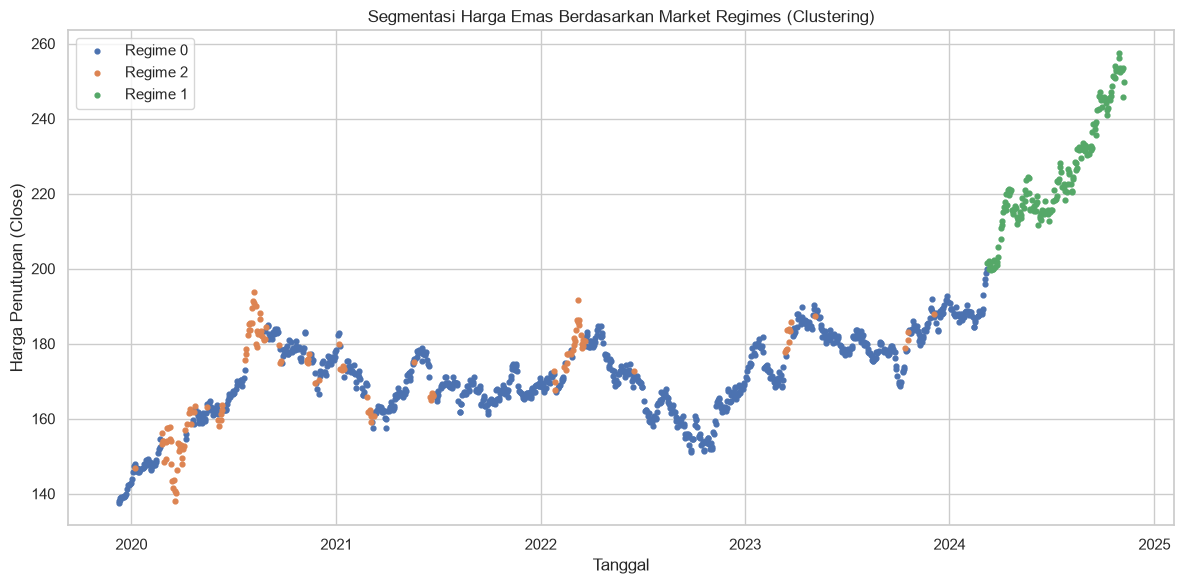

Distribusi Anggota Tiap Cluster/Regime:
Regima
0    925
1    170
2    143
Name: count, dtype: int64


In [48]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Regima'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(12,6))
sns.set_theme(style="whitegrid")
for regime in df['Regima'].unique():
    mask = df['Regima'] == regime
    plt.scatter(df.loc[mask, 'Date'], df.loc[mask, 'Close'], label=f'Regime {regime}', s=12)

plt.title('Segmentasi Harga Emas Berdasarkan Market Regimes (Clustering)')
plt.xlabel('Tanggal')
plt.ylabel('Harga Penutupan (Close)')
plt.legend()
plt.tight_layout()
plt.savefig('gold_regimes.png')
plt.show()

print("Distribusi Anggota Tiap Cluster/Regime:")
print(df['Regima'].value_counts())

# Klasifikasi Menggunakan Fitur Optimal dari ACO
Menjalankan algoritma ACO untuk menyeleksi subset fitur terbaik yang paling diskriminatif dalam memisahkan dan mengklasifikasikan label market regime.

In [49]:
# Jalankan optimasi seleksi fitur berbasis ACO
y_class = df['Regima'].values
aco_optimizer = ACOFeatureSelection(n_ants=10, n_iterations=10, alpha=1.0, evaporation=0.2)
aco_optimizer.fit(X_scaled, y_class)

# Fitur-fitur hasil kurasi koloni semut
selected_features = [feature_cols[i] for i in aco_optimizer.best_features_idx_]
print("Fitur Terpilih Hasil Optimasi ACO:", selected_features)

# Validasi Klasifikasi
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_scaled[:, aco_optimizer.best_features_idx_], y_class, test_size=0.2, random_state=42, stratify=y_class
)

classifier = RandomForestClassifier(n_estimators=50, random_state=42)
classifier.fit(X_train_c, y_train_c)
y_pred_c = classifier.predict(X_test_c)

print(f"Akurasi Klasifikasi Regime Pasar: {accuracy_score(y_test_c, y_pred_c) * 100:.2f}%")

Fitur Terpilih Hasil Optimasi ACO: ['High', 'Volume', 'MA5', 'Vol_MA5', 'Volatility']
Akurasi Klasifikasi Regime Pasar: 97.98%
